# Análisis de Vulnerabilidad Demográfica Covid-19 Perú

### Contexto del proyecto

El dataset a trabajar es: `covid_peru_limpio.csv` el cual fue preparado y limpiado de manera meticulosa. Este dataset contiene registros de casos **positivos de COVID-19 en Perú**.  
Las transformaciones ya aplicadas son:
- Conversión de `FECHA_RESULTADO` y `FECHA_CORTE` a tipo `datetime`
- `EDAD` convertida a tipo `Int64` y filtrada al rango 0–100
- Registros con nulos en variables críticas eliminados
- Duplicados eliminados
- Nueva columna `GRUPO_EDAD` con 6 categorías epidemiológicas
- Fechas inválidas (antes de 2020) eliminadas

**Variables clave para este análisis:** `EDAD`, `SEXO`, `DEPARTAMENTO`, `FECHA_RESULTADO`, `GRUPO_EDAD`

**Objetivo de negocio:** Identificar qué grupos demográficos y regiones son más vulnerables ante futuras olas, para orientar la asignación de recursos (UCI, vacunas, presupuesto).




---
## Fase 01: Carga, Verificacion y Analisis Inicial


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv('./covid_peru_limpio.csv',sep=';')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3338740 entries, 0 to 3338739
Data columns (total 11 columns):
 #   Column           Dtype
---  ------           -----
 0   FECHA_CORTE      str  
 1   DEPARTAMENTO     str  
 2   PROVINCIA        str  
 3   DISTRITO         str  
 4   METODODX         str  
 5   EDAD             int64
 6   SEXO             str  
 7   FECHA_RESULTADO  str  
 8   UBIGEO           int64
 9   ID_PERSONA       int64
 10  GRUPO_EDAD       str  
dtypes: int64(3), str(8)
memory usage: 280.2 MB


In [17]:
# Convertir columna Grupo_Edad a Categoría
orden=[
    '0-17 años (Menores)',
    '18-29 años (Jóvenes)',
    '30-44 años (Adultos Jóvenes)',
    '45-59 años (Adultos)',
    '60-74 años (Adultos Mayores)',
    '75+ años (Tercera Edad)'
]
df['GRUPO_EDAD'] = pd.Categorical(df['GRUPO_EDAD'], categories=orden, ordered=True)
df['GRUPO_EDAD'].unique()

['45-59 años (Adultos)', '60-74 años (Adultos Mayores)', '18-29 años (Jóvenes)', '30-44 años (Adultos Jóvenes)', '75+ años (Tercera Edad)', '0-17 años (Menores)']
Categories (6, str): ['0-17 años (Menores)' < '18-29 años (Jóvenes)' < '30-44 años (Adultos Jóvenes)' < '45-59 años (Adultos)' < '60-74 años (Adultos Mayores)' < '75+ años (Tercera Edad)']

In [18]:
# Formatear números decimales a dos dígitos
pd.options.display.float_format = '{:.2f}'.format
# Mostrar estadisticas clave del DataFrame
df.describe(include='all')

,FECHA_CORTE,DEPARTAMENTO,PROVINCIA,DISTRITO,METODODX,EDAD,SEXO,FECHA_RESULTADO,UBIGEO,ID_PERSONA,GRUPO_EDAD
count,3338740,3338740,3338740,3338740,3338740,3338740.00,3338740,3338740,3338740.00,3338740.00,3338740
unique,1,25,196,1704,3,NaN,2,1458,NaN,NaN,6
top,2024-12-03,LIMA,LIMA,LIMA,AG,NaN,FEMENINO,2022-01-19,NaN,NaN,30-44 años (Adultos Jóvenes)
freq,3338740,1390433,1292929,101691,1553813,NaN,1725974,26280,NaN,NaN,1014525
mean,NaN,NaN,NaN,NaN,NaN,41.57,NaN,NaN,128653.74,43644066.51,NaN
std,NaN,NaN,NaN,NaN,NaN,18.60,NaN,NaN,55111.91,2042140.10,NaN
min,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,10101.00,2130.00,NaN
25%,NaN,NaN,NaN,NaN,NaN,28.00,NaN,NaN,81307.00,42867327.75,NaN
50%,NaN,NaN,NaN,NaN,NaN,40.00,NaN,NaN,150108.00,43736775.50,NaN
75%,NaN,NaN,NaN,NaN,NaN,54.00,NaN,NaN,150137.00,44604917.25,NaN


## DAGRAMA DE CAJA
### Sirve para visualizar la distribución de las edades en los casos positivos de covid y además detectar Outliers

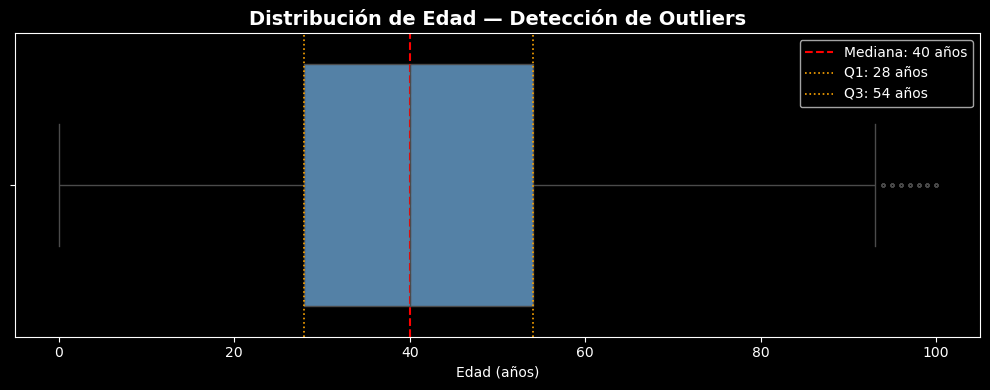

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))

sns.boxplot(x='EDAD', data=df, ax=ax, color='steelblue', flierprops=dict(marker='o', markersize=2, alpha=0.3))

ax.set_title('Distribución de Edad — Detección de Outliers', fontsize=14, fontweight='bold')
ax.set_xlabel('Edad (años)')

q1, mediana, q3 = df['EDAD'].quantile([0.25, 0.50, 0.75])
ax.axvline(mediana, color='red', linestyle='--', linewidth=1.5, label=f'Mediana: {mediana:.0f} años')
ax.axvline(q1, color='orange', linestyle=':', linewidth=1.2, label=f'Q1: {q1:.0f} años')
ax.axvline(q3, color='orange', linestyle=':', linewidth=1.2, label=f'Q3: {q3:.0f} años')
ax.legend()

plt.tight_layout()
plt.show()


  ## Fase 2:
  ## Creación de Dataset: Casos COVID-19 por Departamento y Sexo (2020+)
  ### Consolidación de casos históricos de COVID-19 (2020+) a partir de la data cruda. Se generará un nuevo dataset agrupado por departamento y sexo para facilitar su análisis.



In [26]:
dfnew = pd.read_csv('./poblacion_peru_promedio_20_24.csv',sep=',')

dfnew.info()
dfnew.head(5)
print()

## print dela suma total de la cantidad del total de  hombres y mujeres
print(f"Suma total de hombres: {dfnew['Hombres'].sum()}")
print(f"Suma total de mujeres: {dfnew['Mujeres'].sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Departamento                  25 non-null     str  
 1   Promedio_Poblacion_2020_2024  25 non-null     int64
 2   Hombres                       25 non-null     int64
 3   Mujeres                       25 non-null     int64
dtypes: int64(3), str(1)
memory usage: 932.0 bytes

Suma total de hombres: 16512958
Suma total de mujeres: 16779297


---
## Fase 03: Graficas estadisticas
### Gráfica 1 -Nro de casos por grupo de edad
#### Muestra el numero de contagios de Covid por categoria de edad, muestra que grupo poblacional fue el mas afectado  

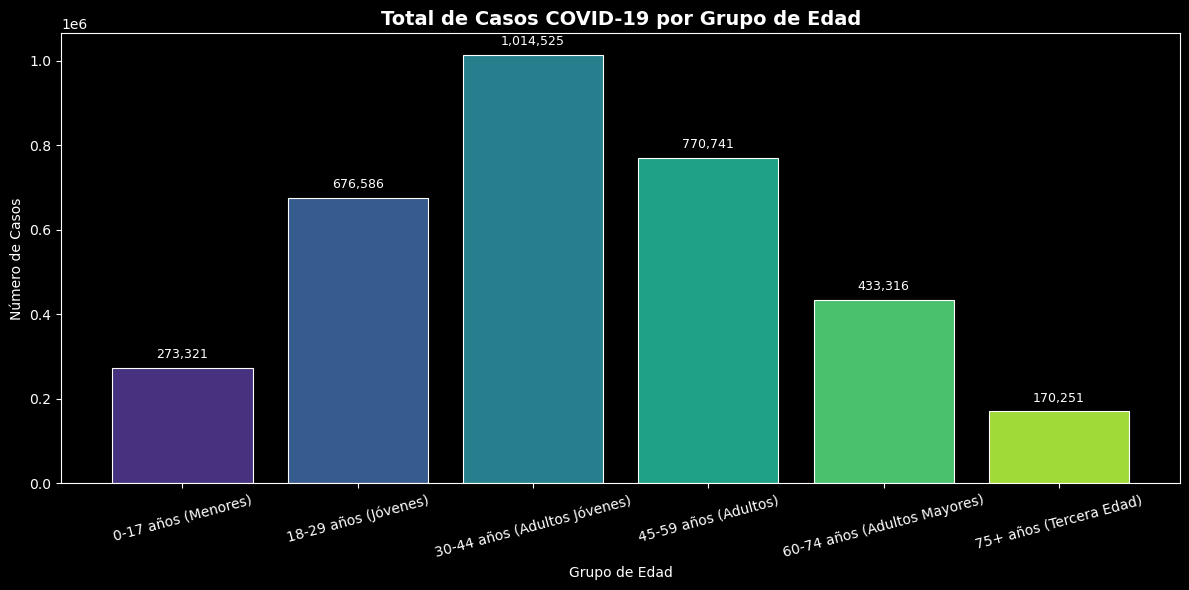

In [21]:
conteo_grupos = df['GRUPO_EDAD'].value_counts().reindex(orden)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    conteo_grupos.index,  
    conteo_grupos.values, 
    color=sns.color_palette('viridis', len(orden)),  
    edgecolor='white',
    linewidth=0.8
)

ax.bar_label(bars, fmt='{:,.0f}', padding=5, fontsize=9)

ax.set_title('Total de Casos COVID-19 por Grupo de Edad', fontsize=14, fontweight='bold')
ax.set_xlabel('Grupo de Edad')
ax.set_ylabel('Número de Casos')
ax.tick_params(axis='x', rotation=15)  

plt.tight_layout()
plt.show()


### Grafica 2 - Casos por sexo
#### 2.1 Graficas Absolutas
#### Muestra la diferencia entre el numero de contagios entre hombres y mujeres de la muestra en dos casos: General y por Categoria de edad 

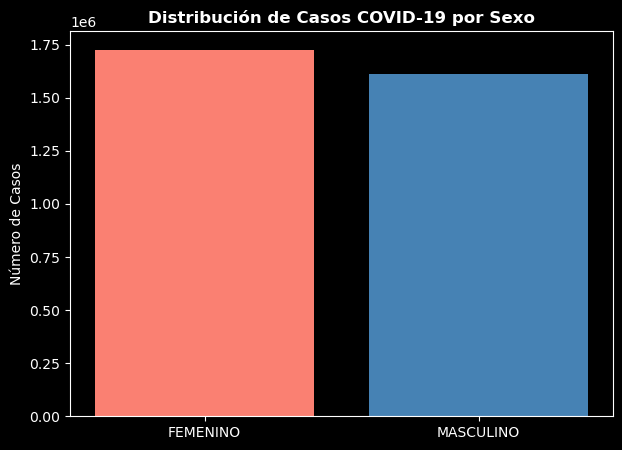

In [24]:
plt.figure(figsize=(7, 5))

conteo = df['SEXO'].value_counts()

plt.bar(conteo.index, conteo.values, color=['salmon', 'steelblue'])

plt.title('Distribución de Casos COVID-19 por Sexo', fontweight='bold')
plt.ylabel('Número de Casos')

plt.show()


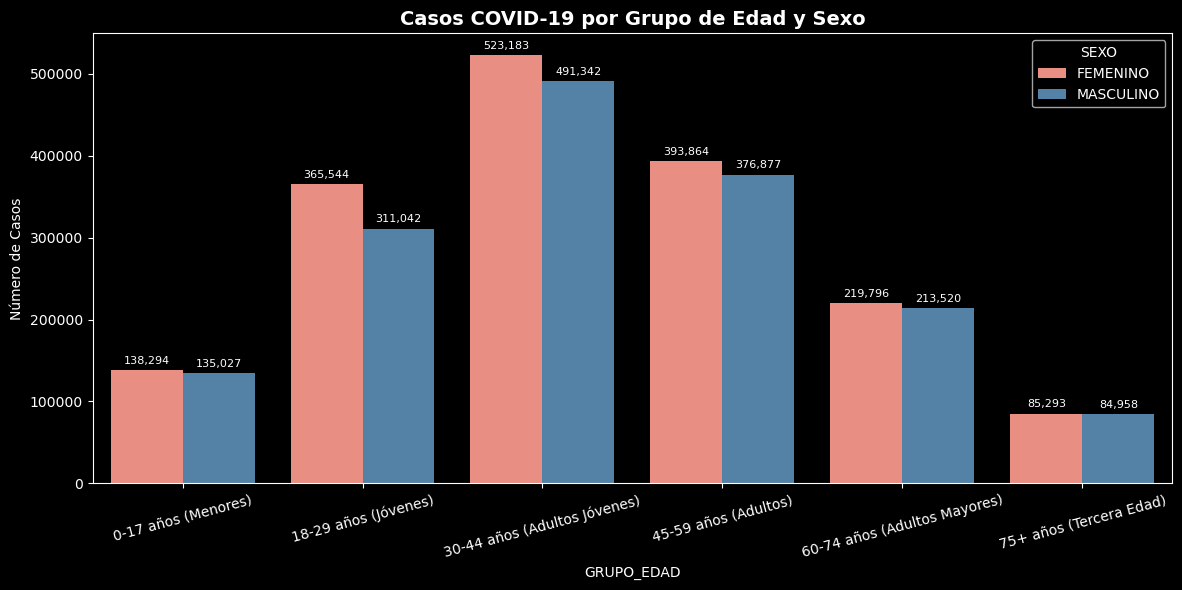

In [23]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df, 
    x='GRUPO_EDAD', 
    y=df.index, 
    hue='SEXO', 
    order=orden,
    palette=['salmon', 'steelblue'], 
    estimator=len 
)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=8)

ax.set_title('Casos COVID-19 por Grupo de Edad y Sexo', fontsize=14, fontweight='bold')
ax.set_ylabel('Número de Casos')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


### 2.2 Graficas Relativas

### Distribución relativa de casos por sexo
#### Calcula el porcentaje de casos sobre la población total de hombres y mujeres del Perú usando el archivo de población promedio 2020-2024.

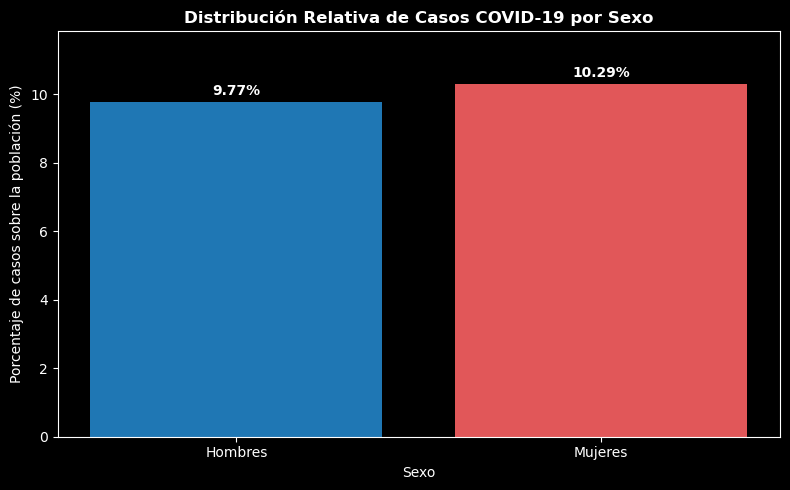

,SEXO,CASOS,POBLACION,PORCENTAJE
0,Hombres,1612766,16512958,9.77
1,Mujeres,1725974,16779297,10.29


In [28]:
casos_por_sexo = (
    df['SEXO']
    .astype(str)
    .str.strip()
    .str.upper()
    .value_counts()
    .reindex(['MASCULINO', 'FEMENINO'], fill_value=0)
)

poblacion_por_sexo = pd.Series({
    'MASCULINO': dfnew['Hombres'].sum(),
    'FEMENINO': dfnew['Mujeres'].sum()
}, name='POBLACION')

analisis_sexo = pd.DataFrame({
    'CASOS': casos_por_sexo,
    'POBLACION': poblacion_por_sexo
})

analisis_sexo['PORCENTAJE'] = (analisis_sexo['CASOS'] / analisis_sexo['POBLACION']) * 100
analisis_sexo = analisis_sexo.reset_index().rename(columns={'index': 'SEXO'})
analisis_sexo['SEXO'] = analisis_sexo['SEXO'].replace({
    'MASCULINO': 'Hombres',
    'FEMENINO': 'Mujeres'
})

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    analisis_sexo['SEXO'],
    analisis_sexo['PORCENTAJE'],
    color=['#1f77b4', '#e15759']
)

ax.bar_label(bars, labels=[f'{valor:.2f}%' for valor in analisis_sexo['PORCENTAJE']], padding=3, fontweight='bold')
ax.set_title('Distribución Relativa de Casos COVID-19 por Sexo', fontweight='bold')
ax.set_ylabel('Porcentaje de casos sobre la población (%)')
ax.set_xlabel('Sexo')
ax.set_ylim(0, analisis_sexo['PORCENTAJE'].max() * 1.15)
plt.tight_layout()
plt.show()

analisis_sexo



### Grafica 3-Departamentos con mas contagios
#### Muestra el top10 de departementos con mas contagios registrados 

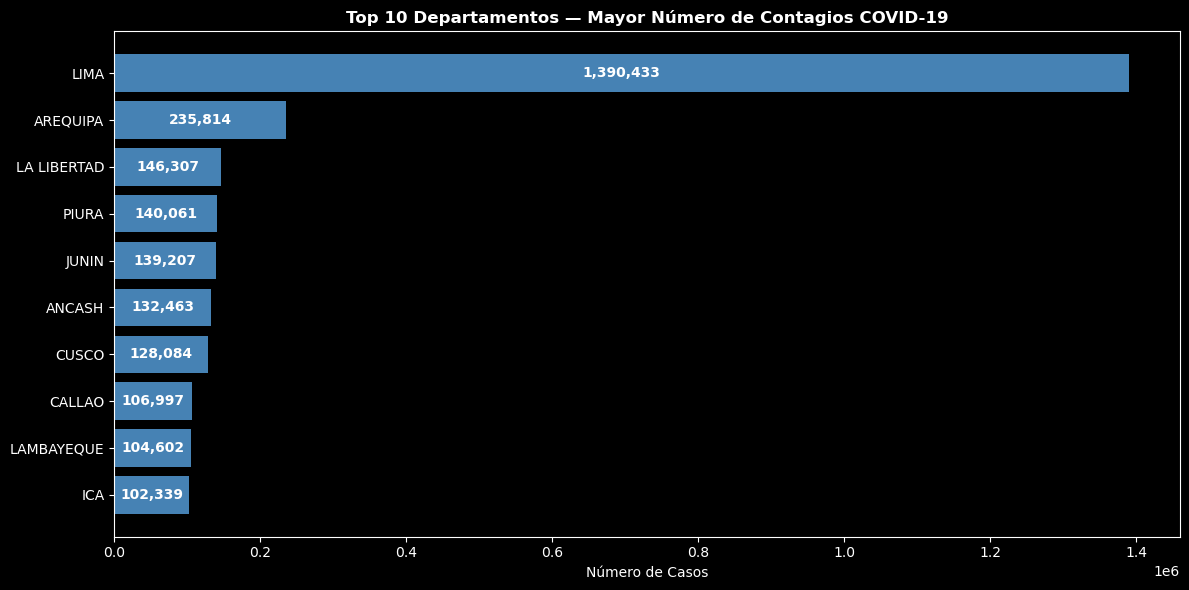

In [36]:
top10_deptos = df['DEPARTAMENTO'].value_counts().nlargest(10).sort_values()


fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_deptos.index, top10_deptos.values, color='steelblue')

ax.bar_label(bars, fmt='{:,.0f}', label_type='center', color='white', fontweight='bold')


ax.set_title('Top 10 Departamentos — Mayor Número de Contagios COVID-19', fontweight='bold')
ax.set_xlabel('Número de Casos')
plt.tight_layout()
plt.show()


#### Muestra el top10 de departamentos mas afectados(%) 

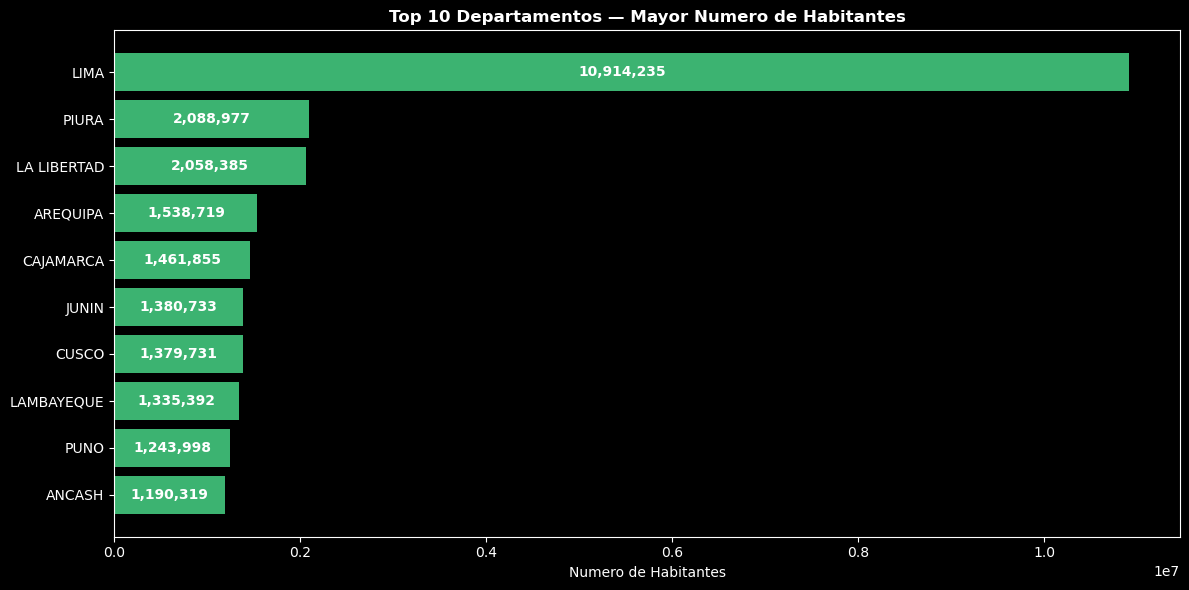

In [33]:
# Usar datos reales desde el CSV de población (sin valores hardcodeados)
df_pob = dfnew[['Departamento', 'Promedio_Poblacion_2020_2024']].copy()

df_pob['DEPARTAMENTO'] = (
    df_pob['Departamento']
    .astype(str)
    .str.strip()
    .str.upper()
    .str.normalize('NFKD')
    .str.encode('ascii', 'ignore')
    .str.decode('utf-8')
)

df_pob = df_pob.rename(columns={'Promedio_Poblacion_2020_2024': 'POBLACION'})
df_pob = df_pob[['DEPARTAMENTO', 'POBLACION']]

deptos_pob = df_pob.nlargest(10, 'POBLACION').sort_values('POBLACION', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(deptos_pob['DEPARTAMENTO'], deptos_pob['POBLACION'], color='mediumseagreen')

ax.bar_label(bars, fmt='{:,.0f}', label_type='center', color='white', fontweight='bold')

ax.set_title('Top 10 Departamentos — Mayor Numero de Habitantes', fontweight='bold')
ax.set_xlabel('Numero de Habitantes')
plt.tight_layout()
plt.show()

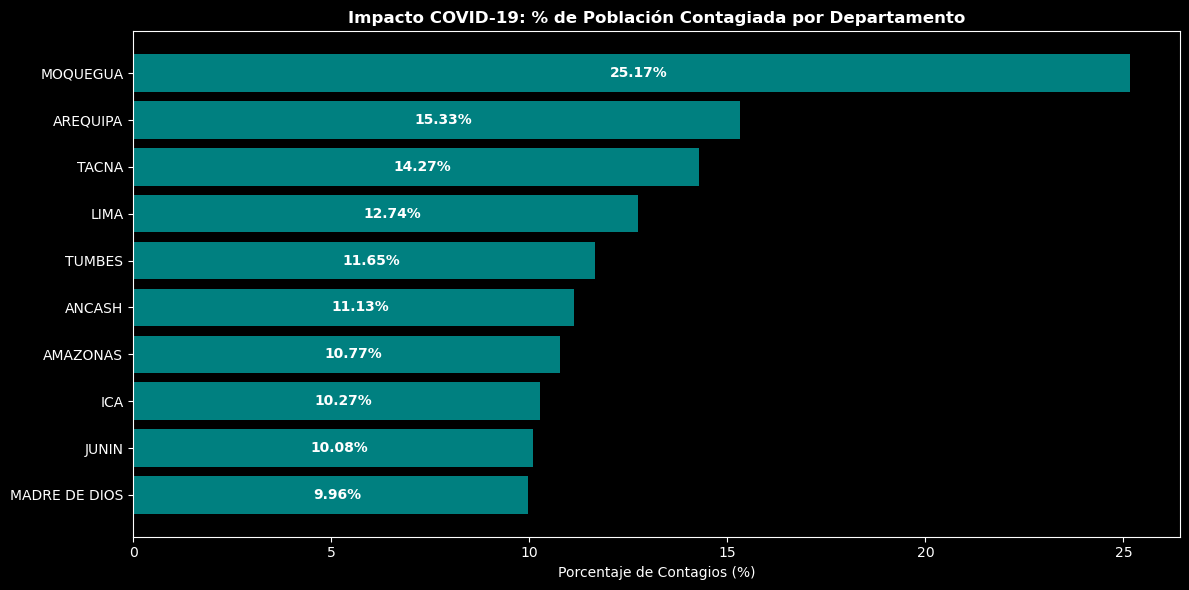

In [34]:
contagios_deptos = df['DEPARTAMENTO'].value_counts().reset_index()
contagios_deptos.columns = ['DEPARTAMENTO', 'CONTAGIOS']

df_analisis = pd.merge(contagios_deptos, df_pob, on='DEPARTAMENTO')

df_analisis['PORCENTAJE'] = (df_analisis['CONTAGIOS'] / df_analisis['POBLACION']) * 100

df_analisis = df_analisis.nlargest(10, 'PORCENTAJE').sort_values('PORCENTAJE', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df_analisis['DEPARTAMENTO'], df_analisis['PORCENTAJE'], color='teal')

ax.bar_label(bars, fmt='%.2f%%', label_type='center', padding=5, fontweight='bold')

ax.set_title('Impacto COVID-19: % de Población Contagiada por Departamento', fontweight='bold')
ax.set_xlabel('Porcentaje de Contagios (%)')
plt.tight_layout()
plt.show()


In [35]:
# Calcular Tasa por cada 100,000 habitantes
df_analisis['Tasa_100k_Hab'] = (df_analisis['CONTAGIOS'] / df_analisis['POBLACION']) * 100000

tabla_tasas = df_analisis[['DEPARTAMENTO', 'Tasa_100k_Hab']].sort_values(by='Tasa_100k_Hab', ascending=False)

print("TABLA DE INCIDENCIA POR DEPARTAMENTO")
print(tabla_tasas.to_string(index=False, formatters={
    'Tasa_100k_Hab': '{:,.0f}'.format
}))


TABLA DE INCIDENCIA POR DEPARTAMENTO
 DEPARTAMENTO Tasa_100k_Hab
     MOQUEGUA        25,168
     AREQUIPA        15,325
        TACNA        14,274
         LIMA        12,740
       TUMBES        11,652
       ANCASH        11,128
     AMAZONAS        10,767
          ICA        10,268
        JUNIN        10,082
MADRE DE DIOS         9,961


---
## Fase 03: Conclusiones

### 3.1 ¿Quiénes se contagiaron más?

- El grupo de **30 a 44 años** tuvo la mayor cantidad de contagios, siendo las **mujeres** las más afectadas dentro de ese rango.
- Sin embargo, los **adultos mayores de 60 años** fueron quienes más murieron u hospitalizaron. Contagiarse más no significa ser el grupo más en riesgo.

---

### 3.2 ¿Dónde fue más fuerte el impacto?

En números totales los 3 departamentos con más casos fueron:

| Departamento | Casos totales |
|---|---|
| Lima | 1,991,910 |
| Arequipa | 298,088 |
| La Libertad | 184,130 |

Pero si miramos qué porcentaje de la población se contagió, el resultado sorprende:

| Departamento | % de población contagiada |
|---|---|
| **Moquegua** | **33.46%** |
| Arequipa | 19.91% |
| Lima | 18.74% |
| Tacna | 18.01% |
| Callao | 14.38% |
| Tumbes | 13.72% |
| Ancash | 13.42% |
| Ica | 12.56% |
| Madre de Dios | 12.26% |
| Amazonas | 12.07% |

**Moquegua fue el más golpeado proporcionalmente: 1 de cada 3 habitantes se contagió**, a pesar de no aparecer entre los primeros en casos totales.

---

### 3.3 Sugerencias

1. **Vacunar y atender primero a los mayores de 60 años** — son los que más riesgo de muerte tienen.
2. **No guiarse solo por los números totales** — regiones pequeñas como Moquegua pueden estar más afectadas de lo que parece.
3. **Reforzar la salud en regiones con pocos recursos** — Moquegua, Tacna y Tumbes tienen tasas altas pero menos hospitales.
4. **Incluir a las mujeres en edad laboral** en campañas de prevención, ya que fueron el grupo con más contagios.